In [21]:
#THIS FUNCTION IS FOR RUNNING WITH SLURM JOB ARRAY
#(SPLITS UP JOB_ARRAY BELOW INTO EVEN MORE TASKS)
def StartSlurmJobArray(num_jobs,num_slurm_jobs, ISRUN):
    job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
    if job_id==0: job_id=1
    if ISRUN==False:
        start_job=1;end_job=num_jobs+1
        return start_job,end_job
    total_elements=num_jobs #total num of variables

    job_range = total_elements // num_slurm_jobs  # Base size for each chunk
    remaining = total_elements % num_slurm_jobs   # Number of chunks with 1 extra 
    
    # Function to compute the start and end for each job_id
    def get_job_range(job_id, num_slurm_jobs):
        job_id-=1
        # Add one extra element to the first 'remaining' chunks
        start_job = job_id * job_range + min(job_id, remaining)
        end_job = start_job + job_range + (1 if job_id < remaining else 0)
    
        if job_id == num_slurm_jobs - 1: 
            end_job = total_elements 
        return start_job, end_job
    # def job_testing():
    #     #TESTING
    #     start=[];end=[]
    #     for job_id in range(1,num_slurm_jobs+1):
    #         start_job, end_job = get_job_range(job_id)
    #         print(start_job,end_job)
    #         start.append(start_job)
    #         end.append(end_job)
    #     print(np.all(start!=end))
    #     print(len(np.unique(start))==len(start))
    #     print(len(np.unique(end))==len(end))
    # job_testing()
    # if sbatch==True:
        
    start_job, end_job = get_job_range(job_id, num_slurm_jobs)
    index_adjust=start_job
    # print(f'start_job = {start_job}, end_job = {end_job}')
    if start_job==0: start_job=1
    if end_job==total_elements: end_job+=1
    return start_job,end_job

# [start_slurm_job,end_slurm_job]=StartSlurmJobArray(num_jobs,num_slurm_jobs,ISRUN=True)
# print(start_slurm_job,end_slurm_job)

In [22]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

In [23]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [24]:
####################################
# SETUP

In [25]:
################################
#ENTRAINMENT DATA_TYPE SETUP #TESTING
PROCESSING=False #if using full entrainment calculations
# PROCESSING=True #if using turbulence-filtered entrainment calculations
################################

In [26]:
################################
#JOB ARRAY SETUP
################################
#*#*
# how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100
if Np_str=='1e6':
    num_jobs=60 #1M parcels
elif Np_str=='50e6':
    num_jobs=200 #50M parcels

num_slurm_jobs=60
##############################

In [27]:
##############################################
#DATA LOADING FUNCTIONS

In [28]:
#INITIALIZE DATA FUNCTION
###############################################################
def InitiateArray(out_file,vars,t_chunk_size,z_chunk_size,t_size=None,z_size=None):
    # Define array dimensions (adjust based on your data)

    if t_size==None:
        t_size = len(data1['time'])  # Number of timesteps
    if z_size==None:
        z_size = len(data1['zh'])    # Number of vertical levels
    
    with h5py.File(out_file, 'w') as f: 
        # Check if the dataset 'theta_e' already exists
        for var_name in vars:
            if var_name not in f:
                # Create a dataset with the full size for all time steps (initially empty)
                f.create_dataset(var_name, 
                                 (t_size, z_size),  # Full size for all timesteps
                                 chunks=(t_chunk_size, z_chunk_size))  # Chunks for time axis to allow resizing

def InitiateArray_Job(data,out_file,vars,t_chunk_size,z_chunk_size,t_size=None,z_size=None):
    # Define array dimensions (adjust based on your data)

    if t_size==None:
        t_size = len(data['time'])  # Number of timesteps
    if z_size==None:
        z_size = len(data1['zh'])    # Number of vertical levels
    
    with h5py.File(out_file, 'w') as f: 
        # Check if the dataset 'theta_e' already exists
        for var_name in vars:
            if var_name not in f:
                # Create a dataset with the full size for all time steps (initially empty)
                f.create_dataset(var_name, 
                                 (t_size, z_size),  # Full size for all timesteps
                                 chunks=(t_chunk_size, z_chunk_size))  # Chunks for time axis to allow resizing

In [29]:
#JOB ARRAY SETUP
def StartJobArray(job_id,num_jobs):
    total_elements=len(data1['time']) #total num of variables

    if num_jobs >= total_elements:
        raise ValueError("Number of jobs cannot be greater than or equal to total elements.")
    
    job_range = total_elements // num_jobs  # Base size for each chunk
    remaining = total_elements % num_jobs   # Number of chunks with 1 extra 
    
    # Function to compute the start and end for each job_id
    def get_job_range(job_id, num_jobs):
        job_id-=1
        # Add one extra element to the first 'remaining' chunks
        start_job = job_id * job_range + min(job_id, remaining)
        end_job = start_job + job_range + (1 if job_id < remaining else 0)
    
        if job_id == num_jobs - 1: 
            end_job = total_elements #- 1
        return start_job, end_job
    # def job_testing():
    #     #TESTING
    #     start=[];end=[]
    #     for job_id in range(1,num_jobs+1):
    #         start_job, end_job = get_job_range(job_id)
    #         print(start_job,end_job)
    #         start.append(start_job)
    #         end.append(end_job)
    #     print(np.all(start!=end))
    #     print(len(np.unique(start))==len(start))
    #     print(len(np.unique(end))==len(end))
    # job_testing()

    # if sbatch==True:
    #     job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
    #     if job_id==0: job_id=1
        
    start_job, end_job = get_job_range(job_id, num_jobs)
    index_adjust=start_job
    # print(f'start_job = {start_job}, end_job = {end_job}')
    return start_job,end_job,index_adjust
# job_id=150
# [start_job,end_job,index_adjust]=StartJobArray(job_id,num_jobs)

In [30]:
# Reading Back Data Later
##############
def make_data_dict(in_file,var_names,read_type,start_job,end_job):
    if read_type=='h5py':
        with h5py.File(in_file, 'r') as f:
            data_dict = {var_name: f[var_name][start_job:end_job] for var_name in var_names}

            
    elif read_type=='xarray':
        in_data = xr.open_dataset(
            in_file,
            engine='h5netcdf',
            phony_dims='sort',
            chunks={'phony_dim_0': 100, 'phony_dim_1': 1_000_000} 
        )
        data_dict = {k: in_data[k][start_job:end_job].compute().data for k in var_names}

    return data_dict

# read_type='xarray'
read_type='h5py'

In [31]:
def GetData(data1,parcel1,start_job,end_job):
    #Indexing Array with JobArray
    data=data1.isel(time=slice(start_job,end_job))
    parcel=parcel1.isel(time=slice(start_job,end_job))
    return data,parcel
# [data,parcel]=GetData(data1,parcel1,start_job,end_job)

In [32]:
def GetSpatialData(data,start_job,end_job):
    import h5py
    dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
    in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'
    
    var_names = ['Z']#, 'Y', 'X']
    data_dict = make_data_dict(in_file,var_names,read_type,start_job,end_job)
    Z, = (data_dict[k] for k in var_names) #,Y,X
    
    # #Making Time Matrix
    Nt=len(data['time'])
    T = np.broadcast_to(np.arange(Nt)[:, None], A_c.shape)  # shape: (Nt, p)
    
    # check_memory(globals())
    return T,Z#,Y,X

In [33]:
def GetAData(PROCESSING,start_job,end_job):
    if PROCESSING==False:
        dir2=dir+'Project_Algorithms/Lagrangian_Arrays/'
        in_file=dir2+f'lagrangian_binary_array_{res}_{t_res}_{Np_str}.h5'
        
        var_names = ['A_g', 'A_c']
        data_dict = make_data_dict(in_file,var_names,read_type,start_job,end_job)
        A_g, A_c = (data_dict[k] for k in var_names) #, W
    
    elif PROCESSING==True:
        dir2=dir+'Project_Algorithms/Entrainment/'
        in_file=dir2+f'processed_binary_arrays_{res}_{t_res}_{Np_str}.h5'
        
        var_names = ['A_g_Processed', 'A_c_Processed']
        data_dict = make_data_dict(in_file,var_names,read_type,start_job,end_job)
        A_g,A_c = (data_dict[k] for k in var_names)
        # check_memory(globals())
    return A_g,A_c

In [34]:
def GetAPrior(PROCESSING,start_job): #FIX FOR JOB_ARRAY (SO FIRST TIMESTEP WILL NOT BE BLANK)
    if start_job!=0:
        A_g_Prior,A_c_Prior=GetAData(PROCESSING,start_job-1,start_job);
        return A_g_Prior,A_c_Prior
    else:
        return 0,0

In [35]:
###########################################################################################################################################################################

In [36]:
####################################
#Functions

In [37]:
def SubtractA(A,A_Prior):
    D = np.zeros_like(A,dtype=np.int8)
    D[1:, :] = A[1:, :]*1 - A[:-1, :]*1
    if start_job!=0:
        D[0, :] = A[0, :]*1-A_Prior*1 #FIX FOR FIRST TIMESTEP
    return D

def AddAs(A1,A2,A2_Prior):
    S = np.zeros_like(A1,dtype=np.int8)
    S[1:, :] = A1[1:, :]*1 + A2[:-1, :]*1
    if start_job!=0:
        S[0, :] = A1[0, :]*1 + A2_Prior*1 #FIX FOR FIRST TIMESTEP
    return S

def Heavyside(D,type):
    if type=='e':
        D[D < 0] = 0
    elif type=='d':
        D[D > 0] = 0
        D*=-1 #not in main entrainment code (where it is not necessary), here only 0s and 1s can be used
    return D

def ed2d(data, A1,A2, T, Z, type,type2, A1_Prior,A2_Prior): #*#*
    # start_time = time.time()
    """
    Function to compute 2D entrainment from general to cloudy and cloudy to general updates
    """

    #TESTING REMOVING ENTRAINMENT/DETRAINMENT SO I CAN JUST SHOW S MATRIXES
    D=np.ones_like(A1) #*#*#
    
    #removing entrainment going from general <==> cloudy updrafts
    #must be either entrained OR detrained from/to environment) AND (NOT move between general and cloudy updrafts)
    S1=AddAs(A1,A2,A2_Prior); S2=AddAs(A2,A1,A1_Prior)
    if type2=='general':
        S=S1 #cloudy to general
    elif type2=='cloudy':
        S=S2 #general to cloudy
    cond=(S==2) #General <==> Cloudy
    D = D & (cond) #*#*#

    # Initialize time and vertical dimension arrays
    Nt = len(data['time']); Nz = len(data1['zh'])
    # Initialize result array
    result = np.zeros((Nt, Nz))

    # Use np.add.at to accumulate values in the result array
    np.add.at(result, (T, Z), D)

    # end_time = time.time()
    # print(f"Execution time: {(end_time - start_time)} seconds")
    return result

In [38]:
def MakeDictionary(**vars):
    return vars
def RunCalculation(data, A_g,A_c, T,Z, A_g_Prior, A_c_Prior):    
    # Set A based on PROCESSING state
    
    profile_array_c_to_g = ed2d(data, A_g,A_c, T, Z, type='e',type2='general', A1_Prior=A_g_Prior, A2_Prior=A_c_Prior)
    profile_array_g_to_c = ed2d(data, A_g,A_c, T, Z, type='e',type2='cloudy', A1_Prior=A_g_Prior, A2_Prior=A_c_Prior)

    VARs=MakeDictionary(profile_array_c_to_g=profile_array_c_to_g, 
                        profile_array_g_to_c=profile_array_g_to_c)
    return VARs

In [39]:
def SaveProfile(VARs,job_id,PROCESSING):
    dir2=dir+'Project_Algorithms/Entrainment/job_out_3/'
    
    #SAVING
    # print('SAVING')
    if PROCESSING==False:
        out_file=dir2+f'2D_entrainmentdetrainment_combined_profiles_{res}_{t_res}_{Np_str}'
    elif PROCESSING==True:
        out_file=dir2+f'2D_entrainmentdetrainment_combined_profiles_PREPROCESSING_{res}_{t_res}_{Np_str}'
    out_file+=f'_{job_id}.h5'
    
    vars=VARs.keys()
    t_chunk_size=end_job-start_job
    z_chunk_size=2
    InitiateArray_Job(data,out_file,vars,t_chunk_size=t_chunk_size,z_chunk_size=z_chunk_size)
    
    with h5py.File(out_file, 'a') as f: 
        for var in VARs:
            f[f'{var}'][:]=VARs[var]
    # print('done')

In [40]:
##############################################
#RUNNING

In [41]:
[start_slurm_job,end_slurm_job]=StartSlurmJobArray(num_jobs=num_jobs,num_slurm_jobs=num_slurm_jobs,ISRUN=False) #if ISRUN is False, then will not run using slurm_job_array

print(f"Running on Slurm_Jobs for Slurm_Job_Ids: {(start_slurm_job,end_slurm_job-1)}")

job_id_list=np.arange(start_slurm_job,end_slurm_job)
for job_id in job_id_list:
    if job_id % 1 == 0: print(f'current job_id = {job_id}')
    [start_job,end_job,index_adjust]=StartJobArray(job_id,num_jobs)

    #SLICING DATA
    [data,parcel]=GetData(data1,parcel1,start_job,end_job)
    [A_g,A_c]=GetAData(PROCESSING,start_job,end_job)
    [A_g_Prior,A_c_Prior]=GetAPrior(PROCESSING,start_job) #FIX FOR FIRST TIMESTEP
    [T,Z]=GetSpatialData(data,start_job,end_job)

    #RUNNING CALCULATION
    VARs=RunCalculation(data, A_g,A_c, T,Z, A_g_Prior,A_c_Prior)

    #SAVING
    SaveProfile(VARs,job_id,PROCESSING)
    # check_memory(globals())
    del VARs

Running on Slurm_Jobs for Slurm_Job_Ids: (1, 60)
current job_id = 1
current job_id = 2
current job_id = 3
current job_id = 4
current job_id = 5
current job_id = 6
current job_id = 7
current job_id = 8
current job_id = 9
current job_id = 10
current job_id = 11
current job_id = 12
current job_id = 13
current job_id = 14
current job_id = 15
current job_id = 16
current job_id = 17
current job_id = 18
current job_id = 19
current job_id = 20
current job_id = 21
current job_id = 22
current job_id = 23
current job_id = 24
current job_id = 25
current job_id = 26
current job_id = 27
current job_id = 28
current job_id = 29
current job_id = 30
current job_id = 31
current job_id = 32
current job_id = 33
current job_id = 34
current job_id = 35
current job_id = 36
current job_id = 37
current job_id = 38
current job_id = 39
current job_id = 40
current job_id = 41
current job_id = 42
current job_id = 43
current job_id = 44
current job_id = 45
current job_id = 46
current job_id = 47
current job_id = 48


In [42]:
#########################################
#RECOMBINE SEPERATE JOB_ARRAYS AFTER
recombine=False #KEEP FALSE IF JOB ARRAY IS RUNNING
recombine=True

In [43]:
def Recombine(PROCESSING,num_jobs):
    dir2=dir+'Project_Algorithms/Entrainment/job_out_3/'
    dir3=dir+'Project_Algorithms/Entrainment/'
    
    if PROCESSING==False:
        out_file=dir3+f'2D_entrainmentdetrainment_combined_profiles_{res}_{t_res}_{Np_str}.h5'
    elif PROCESSING==True:
        out_file=dir3+f'2D_entrainmentdetrainment_combined_profiles_PREPROCESSING_{res}_{t_res}_{Np_str}.h5'
    
    vars=["profile_array_c_to_g","profile_array_g_to_c"]
    InitiateArray(out_file,vars,t_chunk_size=50,z_chunk_size=2)
    
    with h5py.File(out_file, 'r+') as f_out:
        for job_id in np.arange(1,num_jobs+1):
            if np.mod(job_id,10)==0: print(f"job_id = {job_id}")
            [a,b,_]=StartJobArray(job_id,num_jobs)
    
            if PROCESSING==False:
                in_file=dir2+f'2D_entrainmentdetrainment_combined_profiles_{res}_{t_res}_{Np_str}_{job_id}.h5'
            elif PROCESSING==True:
                in_file=dir2+f'2D_entrainmentdetrainment_combined_profiles_PREPROCESSING_{res}_{t_res}_{Np_str}_{job_id}.h5'
            with h5py.File(in_file, 'r') as f_in: 
                for var in vars:
                    f_out[var][a:b]=f_in[var][:]

In [45]:
if recombine==True:
    Recombine(PROCESSING,num_jobs=num_jobs)

job_id = 10
job_id = 20
job_id = 30
job_id = 40
job_id = 50
job_id = 60


In [ ]:
################################################
#TESTING TESTING 

In [63]:

# # dx = 1 km; Np = 1M; Nt = 5 min
# data1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
# parcel1=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
# res='1km';t_res='5min'
# Np_str='1e6'

# job_id=44;num_jobs=60
# print(StartJobArray(job_id,num_jobs))

# # dx = 1km; Np = 50M
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data1=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel1=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# job_id=148;num_jobs=200
# print(StartJobArray(job_id,num_jobs))

(99, 101, 99)
(502, 505, 502)


[[  0.   0.   0.   0.   0.   0.   0.   0.   1.  27.  82. 276. 137.  45.
   27.   5.   4.   3.   1.   4.   6.   3.   1.   1.   2.   1.   1.   0.
    0.   0.   2.   6.   4.   0.]
 [  0.   0.   0.   0.   0.   0.   0.   0.   5.  34.  65. 268. 172.  66.
   26.  11.   6.   3.   3.   2.  10.   5.   1.   1.   1.   0.   0.   1.
    0.   1.   2.   0.   0.   0.]]


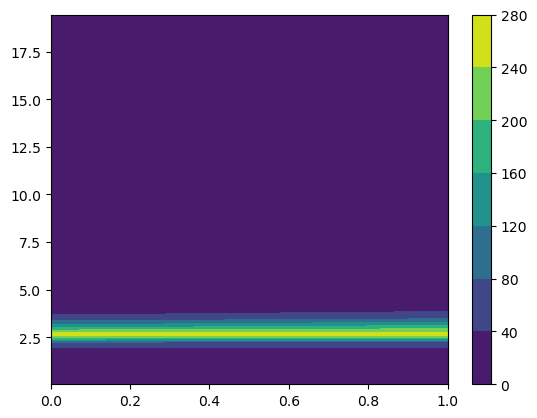

In [102]:
# #TESTING
# res='1km';t_res='5min';Np_str='1e6'

# job_id=44;num_jobs=60
# # print(StartJobArray(job_id,num_jobs))

# dir2=dir+'Project_Algorithms/Entrainment/job_out_3/'
# in_file=dir2+f'2D_entrainmentdetrainment_combined_profiles_PREPROCESSING_{res}_{t_res}_{Np_str}_{job_id}.h5'
# # in_file=dir2+f'2D_entrainmentdetrainment_combined_profiles_{res}_{t_res}_{Np_str}_{job_id}.h5'
# with h5py.File(in_file,'r') as f:
#     g_to_c=f['profile_array_g_to_c'][:]
# print(g_to_c)

# #####
# x=np.arange(g_to_c.shape[0])
# y=data1['zh'].data
# plt.contourf(x,y,g_to_c.T)
# plt.colorbar()

[[    0.     0.     0.     0.     0.     0.     0.     0.   503.  3096.
   6243. 22484.  4257.  3773.  3279.  3080.  2595.  2237.  1388.  1288.
    977.  1266.  1025.   926.   660.   852.   261.   514.   206.    81.
    189.    94.    41.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.   476.  3345.
   6291. 22311.  4389.  3869.  2860.  3083.  2948.  2103.  1425.  1285.
   1185.  1044.  1293.   832.   735.   771.   499.   550.   323.   127.
    217.   172.    27.     0.]
 [    0.     0.     0.     0.     0.     0.     0.     0.   340.  3317.
   5881. 22561.  4755.  3811.  3136.  3448.  3223.  2454.  1531.  1307.
   1038.  1461.  1226.   919.   629.   653.   440.   700.   305.   186.
     97.   251.    45.     0.]]


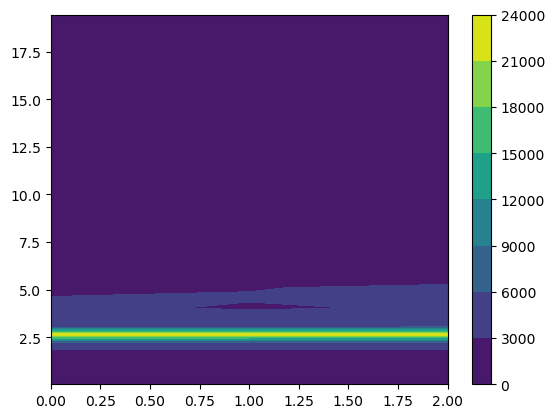

In [104]:
#TESTING
res='1km';t_res='1min';Np_str='50e6'

job_id=148;num_jobs=200
# print(StartJobArray(job_id,num_jobs))

dir2=dir+'Project_Algorithms/Entrainment/job_out_3/'
in_file=dir2+f'2D_entrainmentdetrainment_combined_profiles_PREPROCESSING_{res}_{t_res}_{Np_str}_{job_id}.h5'
in_file=dir2+f'2D_entrainmentdetrainment_combined_profiles_{res}_{t_res}_{Np_str}_{job_id}.h5'
with h5py.File(in_file,'r') as f:
    g_to_c=f['profile_array_g_to_c'][:]
print(g_to_c)

#####
x=np.arange(g_to_c.shape[0])
y=data1['zh'].data
plt.contourf(x,y,g_to_c.T)
plt.colorbar()